# Chapter 64 — Sigmoid Functions

> **Prerequisites:** ch055 (Inverse Functions), ch063 (Step Functions)
>
> **You will learn:**
> - Define sigmoid functions and their key properties
> - Derive logistic function from logit transform
> - Understand why sigmoid smoothly approximates the step function
> - Connect sigmoid to probability, log-odds, and logistic regression
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **sigmoid function** is any function shaped like the letter S: monotonically increasing, bounded above and below, with an inflection point in the middle.

The most common is the **logistic function**:
σ(x) = 1 / (1 + e^(-x))

Properties:
- σ(x) ∈ (0, 1) for all x ∈ ℝ
- σ(0) = 0.5
- σ(-x) = 1 - σ(x) (antisymmetric around (0, 0.5))
- σ'(x) = σ(x)(1 - σ(x)) — the derivative is expressible in terms of itself
- lim_{x→+∞} σ(x) = 1, lim_{x→-∞} σ(x) = 0

**The sigmoid smooths the Heaviside step function.** As a parameter k increases in 1/(1+e^(-kx)), the curve steepens toward a step at x=0.

**Logit (inverse sigmoid):** logit(p) = log(p/(1-p)) — converts probability to log-odds. σ and logit are inverses (introduced in ch055).

---

## 2. Intuition & Mental Models

**Physical analogy:** A dimmer switch. A step switch is on or off. A sigmoid dimmer smoothly transitions from fully off (0) to fully on (1). The steepness parameter k controls how sharp the transition is.

**Computational analogy:** In logistic regression, σ(wᵀx + b) outputs a probability. The sigmoid converts an unbounded linear score into a bounded [0,1] probability. That's its exact role in the model.

Recall from ch063 (Step Functions): Heaviside is the limiting case of sigmoid as steepness → ∞.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_11788\1138602643.py:36: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


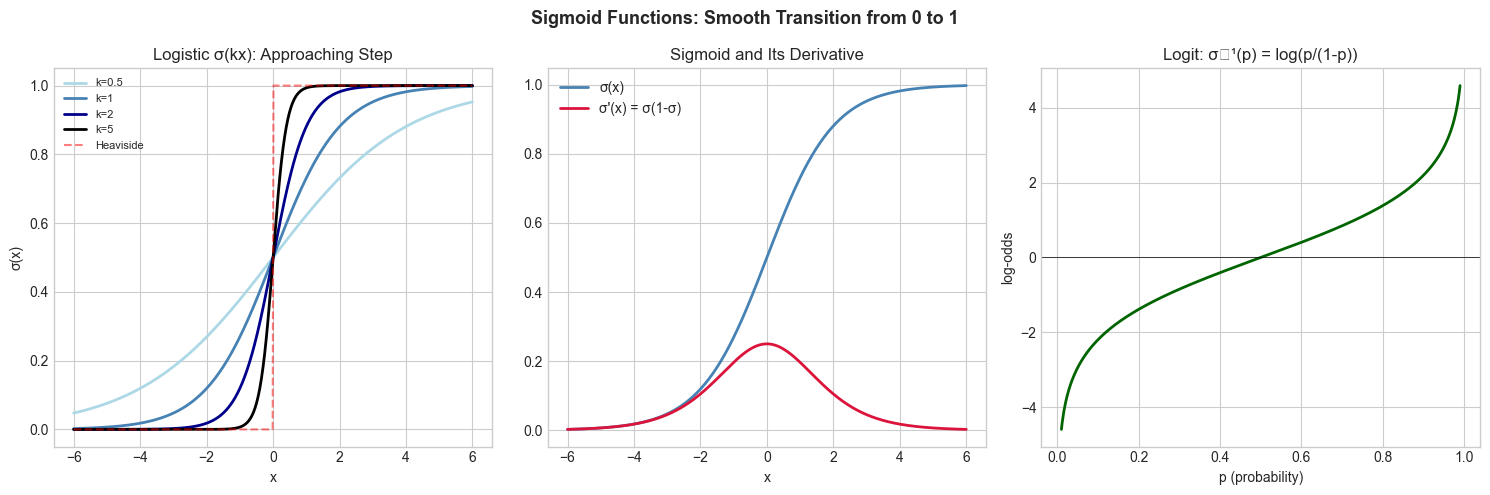

In [1]:
# --- Visualization: Sigmoid family and steepness ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-6, 6, 500)

def logistic(x, k=1): return 1 / (1 + np.exp(-k * x))
def tanh_norm(x): return (np.tanh(x) + 1) / 2  # shifted to [0,1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Effect of steepness
for k, color in zip([0.5, 1, 2, 5], ['lightblue','steelblue','darkblue','black']):
    axes[0].plot(x, logistic(x, k), color=color, linewidth=2, label=f'k={k}')
axes[0].plot(x, np.where(x>=0, 1, 0), 'r--', linewidth=1.5, alpha=0.5, label='Heaviside')
axes[0].set_title('Logistic σ(kx): Approaching Step')
axes[0].set_xlabel('x'); axes[0].set_ylabel('σ(x)')
axes[0].legend(fontsize=8)

# Derivative
sx = logistic(x)
axes[1].plot(x, sx, color='steelblue', linewidth=2, label='σ(x)')
axes[1].plot(x, sx*(1-sx), color='crimson', linewidth=2, label="σ'(x) = σ(1-σ)")
axes[1].set_title("Sigmoid and Its Derivative")
axes[1].set_xlabel('x'); axes[1].legend()

# Logit (inverse)
p = np.linspace(0.01, 0.99, 500)
axes[2].plot(p, np.log(p/(1-p)), color='darkgreen', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Logit: σ⁻¹(p) = log(p/(1-p))')
axes[2].set_xlabel('p (probability)'); axes[2].set_ylabel('log-odds')

plt.suptitle('Sigmoid Functions: Smooth Transition from 0 to 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Logistic sigmoid:** σ(x) = 1/(1 + e^(-x))

**Key identity:** σ'(x) = σ(x)·(1 - σ(x))
This makes gradient computation in logistic regression and neural networks particularly clean.

**Logit (inverse):** logit(p) = ln(p/(1-p)) = ln(p) - ln(1-p)

**Probability interpretation:** If x = log-odds = ln(P/(1-P)), then σ(x) = P.

**tanh relationship:** tanh(x) = 2σ(2x) - 1 — tanh is a rescaled sigmoid

In [2]:
# --- Implementation: Numerically stable sigmoid ---
import numpy as np

def sigmoid(x):
    """
    Numerically stable sigmoid: 1 / (1 + e^(-x)).
    Avoids overflow for large negative x.
    
    Args:
        x: np.ndarray or scalar
    Returns:
        sigmoid values in (0, 1)
    """
    x = np.asarray(x, dtype=float)
    # For large positive x, use 1 - sigmoid(-x) to avoid exp overflow
    return np.where(x >= 0,
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))

def sigmoid_derivative(x):
    """σ'(x) = σ(x)(1 - σ(x))."""
    s = sigmoid(x)
    return s * (1 - s)

def logit(p, eps=1e-7):
    """Inverse sigmoid: ln(p/(1-p)). Clips to avoid log(0)."""
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

# Verify round-trip
x_test = np.array([-5, -2, 0, 2, 5])
p_test = sigmoid(x_test)
x_recovered = logit(p_test)
print("x:          ", x_test)
print("σ(x):       ", p_test.round(4))
print("logit(σ(x)):", x_recovered.round(4))
print("Stable for large |x|:", sigmoid(np.array([-1000., 1000.]))  )

x:           [-5 -2  0  2  5]
σ(x):        [0.0067 0.1192 0.5    0.8808 0.9933]
logit(σ(x)): [-5. -2.  0.  2.  5.]
Stable for large |x|: [0. 1.]


C:\Users\user\AppData\Local\Temp\ipykernel_11788\2494554253.py:17: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-x)),
C:\Users\user\AppData\Local\Temp\ipykernel_11788\2494554253.py:18: RuntimeWarning: overflow encountered in exp
  np.exp(x) / (1 + np.exp(x)))
C:\Users\user\AppData\Local\Temp\ipykernel_11788\2494554253.py:18: RuntimeWarning: invalid value encountered in divide
  np.exp(x) / (1 + np.exp(x)))


---

## 6. Experiments

**Experiment 1:** Plot σ(x) and σ'(x) together. Note that σ'(x) is maximized at x=0 where σ=0.5. This means gradients are largest at σ=0.5 and vanish near 0 or 1 — this is the 'vanishing gradient' problem in deep networks.

**Experiment 2:** Compare sigmoid to a piecewise linear approximation: max(0, min(1, x/4 + 0.5)). They look similar but behave differently at extremes.

---

## 7. Exercises

**Easy 1.** Compute σ(0), σ(1), σ(-1), σ(10), σ(-10) by hand and verify with code. *(Expected: 0.5, 0.731, 0.269, ≈1, ≈0)*

**Easy 2.** Verify the identity tanh(x) = 2σ(2x) - 1 numerically for x ∈ {-2, -1, 0, 1, 2}.

**Medium 1.** Implement logistic regression prediction: given weight vector w, bias b, and input matrix X (n×d), compute σ(X @ w + b). Apply to a 2-class dataset and visualize the decision boundary.

**Medium 2.** The softmax function generalizes sigmoid to K classes: softmax(x)ᵢ = e^xᵢ / Σⱼ e^xʲ. Implement a numerically stable version (subtract max before exponentiating). Verify outputs sum to 1.

**Hard.** Derive the gradient of binary cross-entropy loss L = -[y·log σ(x) + (1-y)·log(1-σ(x))] with respect to x. Show that ∂L/∂x = σ(x) - y. Verify numerically with finite differences.

---

## 9. Chapter Summary & Connections

- Logistic sigmoid σ(x) = 1/(1+e^(-x)): smooth, bounded in (0,1)
- σ'(x) = σ(x)(1-σ(x)): elegant self-referential derivative
- Logit is the inverse: converts probability to log-odds
- Sigmoid smoothly approximates the step function as steepness increases

**Forward connections:**
- ch065 (Activation Functions) catalogs the full ML activation function family
- Logistic regression in ch229 uses sigmoid as its core prediction function
- Vanishing gradients in deep networks (ch216) are caused by sigmoid saturation